In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

print(nav_df.shape)

nav_df.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df["daily_return"] = nav_df.groupby(
    "amfi_code"
)["nav"].pct_change()

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


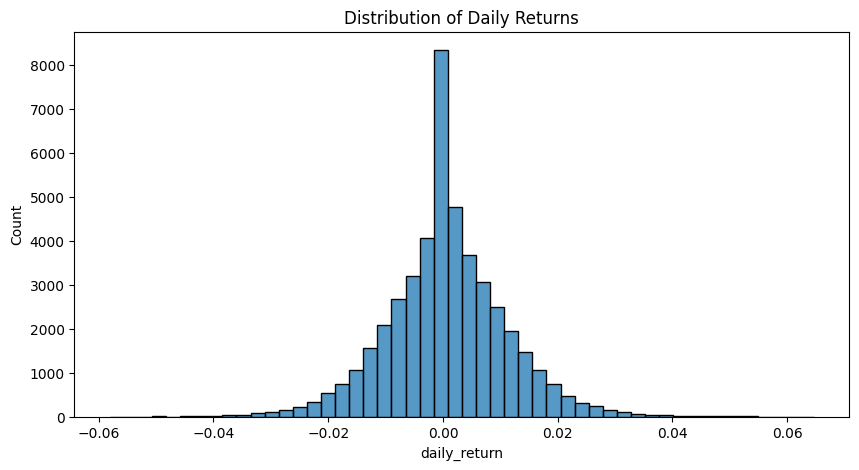

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.show()

In [6]:
cagr_results = []

for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ].sort_values("date")

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        fund_data["date"].max() -
        fund_data["date"].min()
    ).days / 365

    cagr = (
        (end_nav / start_nav) **
        (1 / years)
    ) - 1

    cagr_results.append(
        [fund, cagr * 100]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


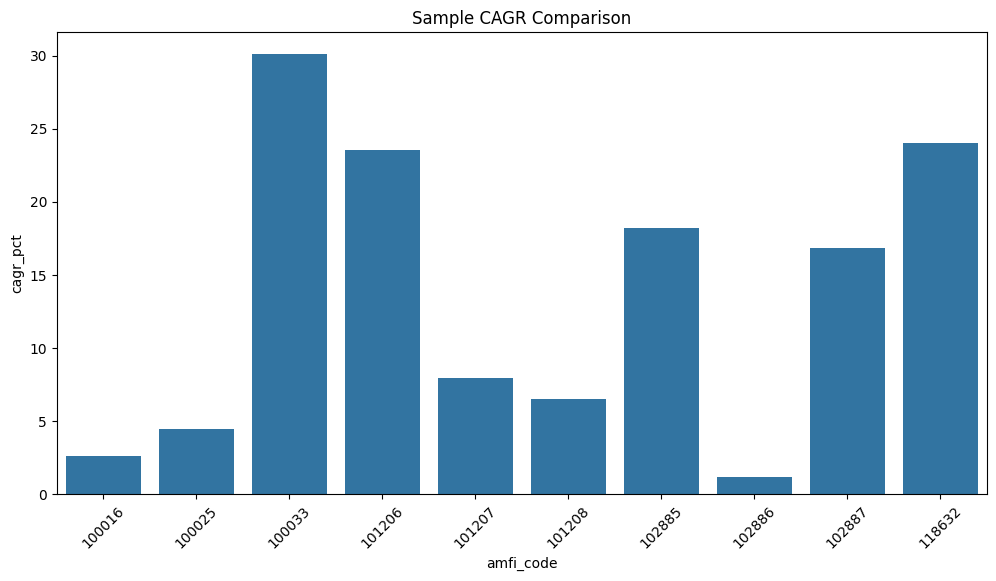

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=cagr_df.head(10),
    x="amfi_code",
    y="cagr_pct"
)

plt.title("Sample CAGR Comparison")
plt.xticks(rotation=45)

plt.show()

In [8]:
rf = 0.065

sharpe_results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    std_return = fund_returns.std()

    sharpe = (
        (avg_return - rf/252)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [9]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


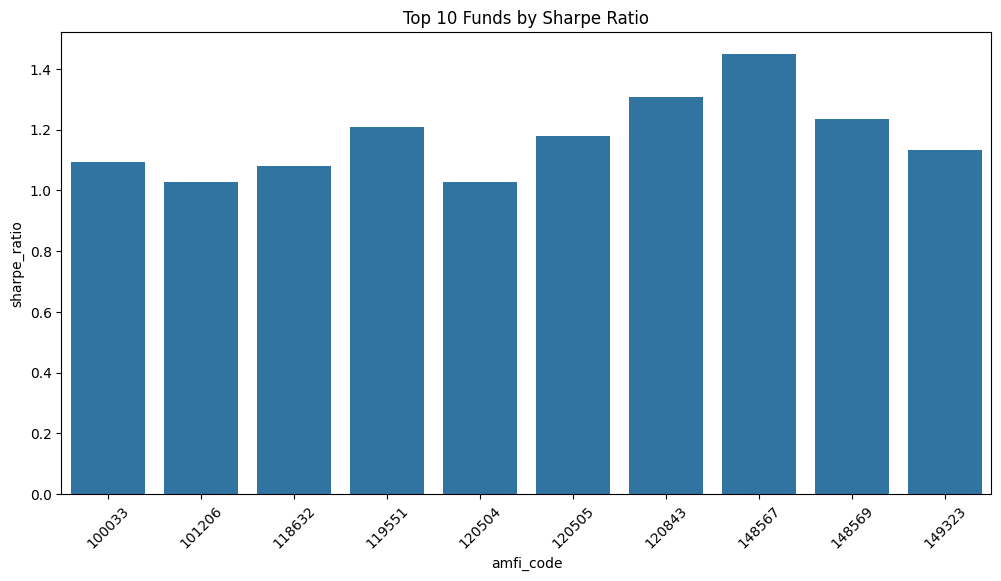

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xticks(rotation=45)

plt.show()

In [11]:
rf = 0.065

sortino_results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    downside_returns = fund_returns[
        fund_returns < 0
    ]

    downside_std = downside_returns.std()

    sortino = (
        (avg_return - rf/252)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [12]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


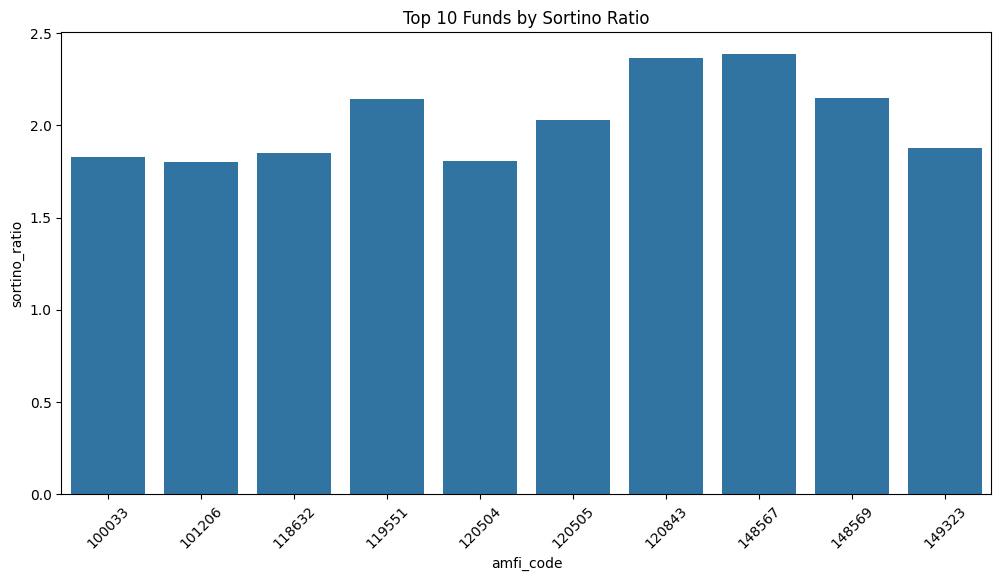

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_df.head(10),
    x="amfi_code",
    y="sortino_ratio"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xticks(rotation=45)

plt.show()

In [14]:
import os
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', '118632_nav.csv', '119092_nav.csv', '119551_nav.csv', '120503_nav.csv', '120841_nav.csv', 'sbi_small_cap_nav.csv']


In [15]:
benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark_df.columns)

benchmark_df.head()

Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [16]:
benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

benchmark_df["daily_return"] = (
    benchmark_df.groupby("index_name")
    ["close_value"]
    .pct_change()
)

benchmark_df.head()

,date,index_name,close_value,daily_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [17]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [18]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100[
    ["date", "daily_return"]
]

nifty100.head()

,date,daily_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [19]:
alpha_beta_results = []

for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100,
        on="date",
        suffixes=("_fund", "_market")
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, std = linregress(
            merged["daily_return_market"],
            merged["daily_return_fund"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [20]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [21]:
top_alpha = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

top_alpha.head(10)

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


In [22]:
drawdown_results = []

for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ].sort_values("date")

    running_max = fund_data["nav"].cummax()

    drawdown = (
        fund_data["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [23]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


In [24]:
drawdown_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [25]:
cagr_df.columns

Index(['amfi_code', 'cagr_pct'], dtype='str')

In [26]:
sharpe_df.columns

Index(['amfi_code', 'sharpe_ratio'], dtype='str')

In [27]:
drawdown_df.columns

Index(['amfi_code', 'max_drawdown'], dtype='str')

In [28]:
scorecard_df = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard_df.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha,max_drawdown
0,100016,2.635246,-0.201517,0.037476,-0.247344
1,100025,4.455091,-0.567095,0.042818,-0.043083
2,100033,30.099704,1.093699,0.271954,-0.162172
3,101206,23.520489,1.027213,0.213998,-0.112916
4,101207,7.933121,0.162661,0.108971,-0.354469


In [29]:
scorecard_df["cagr_rank"] = scorecard_df["cagr_pct"].rank(
    ascending=False
)

scorecard_df["sharpe_rank"] = scorecard_df["sharpe_ratio"].rank(
    ascending=False
)

scorecard_df["alpha_rank"] = scorecard_df["alpha"].rank(
    ascending=False
)

scorecard_df["drawdown_rank"] = scorecard_df["max_drawdown"].rank(
    ascending=False
)

In [30]:
scorecard_df["fund_score"] = (
    scorecard_df["cagr_rank"] * 0.30 +
    scorecard_df["sharpe_rank"] * 0.25 +
    scorecard_df["alpha_rank"] * 0.20 +
    scorecard_df["drawdown_rank"] * 0.10
)

scorecard_df = scorecard_df.sort_values(
    "fund_score"
)

scorecard_df.head(10)

,amfi_code,cagr_pct,sharpe_ratio,alpha,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score
34,148567,30.949920,1.448291,0.269838,-0.112657,5.0,1.0,7.0,8.0,3.95
30,120843,30.883326,1.306744,0.273305,-0.129740,6.0,2.0,5.0,13.0,4.60
25,120505,32.801599,1.180101,0.292636,-0.181885,1.0,5.0,3.0,25.0,4.65
36,148569,31.924486,1.234930,0.282704,-0.163967,4.0,3.0,4.0,21.0,4.85
2,100033,30.099704,1.093699,0.271954,-0.162172,7.0,7.0,6.0,20.0,7.05
38,149323,29.558105,1.132122,0.265986,-0.172481,8.0,6.0,8.0,22.0,7.70
19,119551,25.784921,1.208267,0.232010,-0.150124,10.0,4.0,10.0,17.0,7.70
21,119598,32.398084,0.945308,0.303370,-0.287060,2.0,14.0,1.0,36.0,7.90
39,149324,32.262108,0.949796,0.300579,-0.311719,3.0,13.0,2.0,37.0,8.25
3,101206,23.520489,1.027213,0.213998,-0.112916,12.0,9.0,12.0,9.0,9.15


In [31]:
scorecard_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")


fund_scorecard.csv saved


In [32]:
top5_funds = scorecard_df.head(5)["amfi_code"]

top5_funds

34    148567
30    120843
25    120505
36    148569
2     100033
Name: amfi_code, dtype: int64

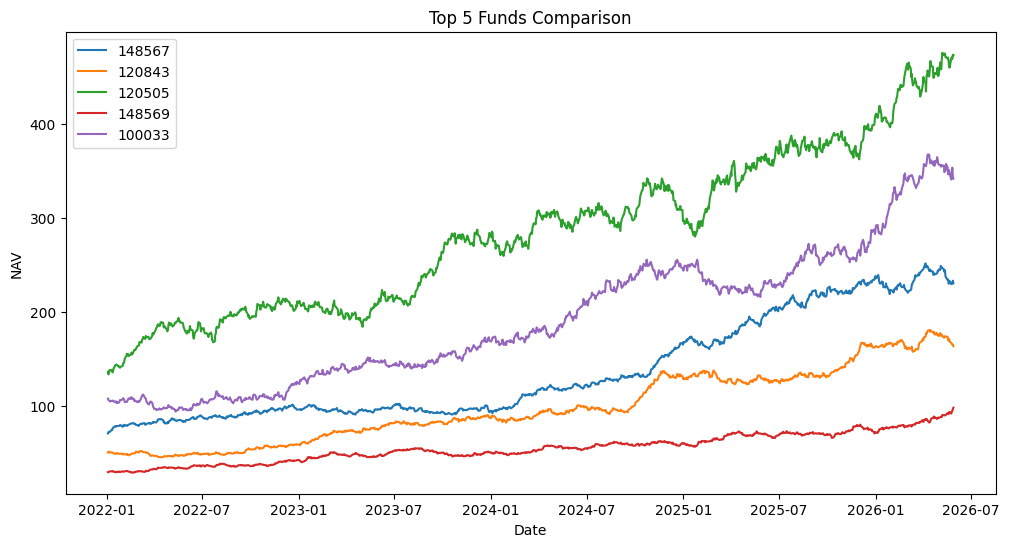

In [33]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund)
    )

plt.title("Top 5 Funds Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.show()

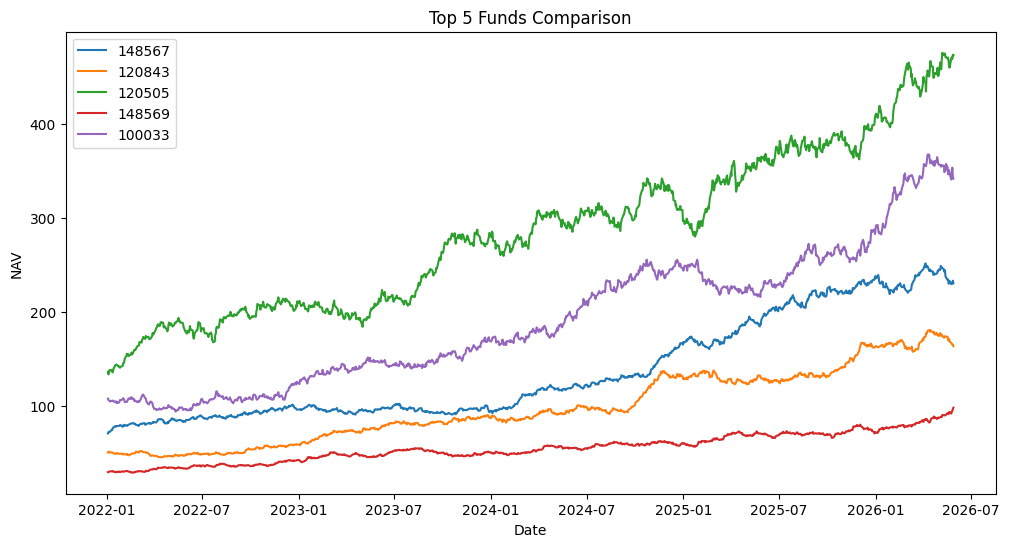

In [34]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund)
    )

plt.title("Top 5 Funds Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()